# Project 3
## Julian Barth, Aloïsse Dantant-Cochet, Arsenijs Danilko, Marin Desgeans, Robin Elkaim

## Table of Contents

* [Exercise 1: Chemostat with Cell Recycle](#exercise-1-chemostat-with-cell-recycle)
* [Exercise 2: Exercise 2: Fed-Batch Penicillin Production](#exercise-2-fed-batch-penicillin-production)
* [Exercise 3: Two continuous stirred tank reactors in series](#exercise-3-two-continuous-stirred-tank-reactors-cstrs-in-series)
* [Bonus: Chemostat with mixed growth](#bonus---chemostat-with-mixed-growth-associated-product-formation-luedeking-piret)

# Exercise 1: Chemostat with Cell Recycle


In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Params
Yxs   = 0.5    # g-cells / g-substrate
S0    = 2.0    # g/L  (feed substrate)
F     = 1500   # mL/h
V     = 1000   # mL
mu_m  = 1.0    # h^-1
Ks    = 0.01   # g/L
alpha = 0.5    # recycle ratio
C     = 2.0    # concentration factor

D = F / V      # dilution rate [h^-1]


## Part (a): Mass balance on cell concentration — showing μ < D at steady state

**Cell mass balance around the fermenter** (in – out + generation = accumulation = 0 at SS):

$$\underbrace{F \cdot X_0}_{\text{feed}} + \underbrace{\alpha F \cdot C X_1}_{\text{recycle in}} - \underbrace{(1+\alpha)F \cdot X_1}_{\text{out}} + \underbrace{\mu X_1 V}_{\text{growth}} = 0$$

Since $X_0 = 0$:
$$\alpha F C X_1 - (1+\alpha)F X_1 + \mu X_1 V = 0$$

Dividing by $X_1 V$ (assuming $X_1 \neq 0$):
$$\mu = D\left[(1+\alpha) - \alpha C\right] = D\left[1 + \alpha(1-C)\right]$$

where $D = F/V$.

Since $C > 1$ (concentrator), the term $\alpha(1-C) < 0$, so:
$$\boxed{\mu = D[1 + \alpha(1-C)] < D}$$

The chemostat **can therefore operate at dilution rates $D$ higher than the specific growth rate $\mu$**, because the cell recycle retains biomass in the reactor, partially decoupling residence time from cell washout.

## Part (b)

In [3]:
# From part (a):
mu = D * (1 + alpha * (1 - C))

print(f"\n  μ = {mu:.4f} h⁻¹")
print(f"  D = {D:.4f} h⁻¹  →  μ < D confirmed: {mu < D}")


  μ = 0.7500 h⁻¹
  D = 1.5000 h⁻¹  →  μ < D confirmed: True


## Part (c)

The Monod equation 
$$\mu = \frac{\mu_m \cdot S}{K_s + S} $$
Rearraning, becomes:
$$S = \frac{\mu \cdot K_s}{\mu_m - \mu} $$

In [4]:
# Rearranged Monod equation
S = mu * Ks / (mu_m - mu)

print(f"\n  S = {S:.5f} g/L")
print(f"  (This is the steady-state substrate concentration inside the reactor)")


  S = 0.03000 g/L
  (This is the steady-state substrate concentration inside the reactor)


## Part (d)

Substrate balance around fermenter:
$$F \cdot S_0 + \alpha F \cdot S - (1 + \alpha)F\cdot S - \frac{\mu}{Y_{xs}} \cdot X_1 \cdot V = 0$$
$$=> F\cdot (S_0 - S) = \frac{\mu}{Y_{xs}} \cdot X_1 \cdot V$$
$$=> X_1 = Y_{xs} \cdot D \cdot \frac{(S_0 - S)}{\mu}$$

In [5]:
X1 = Yxs * D * (S0 - S) / mu
print(f"X₁ = {X1:.4f} g/L")
print(f"(Cell concentration inside the fermenter / recycle stream)")

X₁ = 1.9700 g/L
(Cell concentration inside the fermenter / recycle stream)


## Part (e)

Cell balance around cell separator (no reaction)
$$(1 + \alpha)F \cdot X_1 = \alpha F \cdot (C \cdot X_1) + F \cdot X_2$$
$$=> X_2 = X_1 \cdot [1 + \alpha(1 - C)]$$

In [6]:
X2 = X1 * (1 + alpha * (1 - C))
print(f"X₂ = {X2:.4f} g/L")

X₂ = 0.9850 g/L



## Part (f):

### Range for α

From part (a): $\mu = D[1 + \alpha(1-C)]$

For cells to grow, we need $\mu > 0$ and $\mu \leq \mu_m$. At washout, $\mu \to \mu_m$:

$$D_{max} = \frac{\mu_m}{1 + \alpha(1-C)}$$

For $D_{max} > 0$ and physically meaningful (no negative growth), we need:
$$1 + \alpha(1-C) > 0 \implies \alpha < \frac{1}{C-1}$$

Also $\alpha \geq 0$, so: $\boxed{0 \leq \alpha < \dfrac{1}{C-1}}$

For $C=2$: $0 \leq \alpha < 1$.

### α = 0 means no recycle — the system reduces to a standard chemostat.
In that case $D_{max} = \mu_m$ (classic washout condition).

In [7]:
# D_max as a function of α  (for fixed C=2)
alpha_max = 1/(C - 1)   # upper bound on α
print(f"For C = {C}: valid range 0 ≤ α < {alpha_max:.3f}")
print(f"D_max formula: D_max = μ_m / [1 + α(1-C)]")
print()

alpha_vals = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9])  # different α values
alpha_range = np.linspace(0, alpha_max * 0.99, 200)

Dmax_vals = mu_m / (1 + alpha_range * (1 - C))

print("D_max for selected α values:")
for a in alpha_vals:
    dmax = mu_m / (1 + a*(1-C))
    print(f"  α = {a:.1f}  →  D_max = {dmax:.4f} h⁻¹")

For C = 2.0: valid range 0 ≤ α < 1.000
D_max formula: D_max = μ_m / [1 + α(1-C)]

D_max for selected α values:
  α = 0.0  →  D_max = 1.0000 h⁻¹
  α = 0.2  →  D_max = 1.2500 h⁻¹
  α = 0.4  →  D_max = 1.6667 h⁻¹
  α = 0.6  →  D_max = 2.5000 h⁻¹
  α = 0.8  →  D_max = 5.0000 h⁻¹
  α = 0.9  →  D_max = 10.0000 h⁻¹


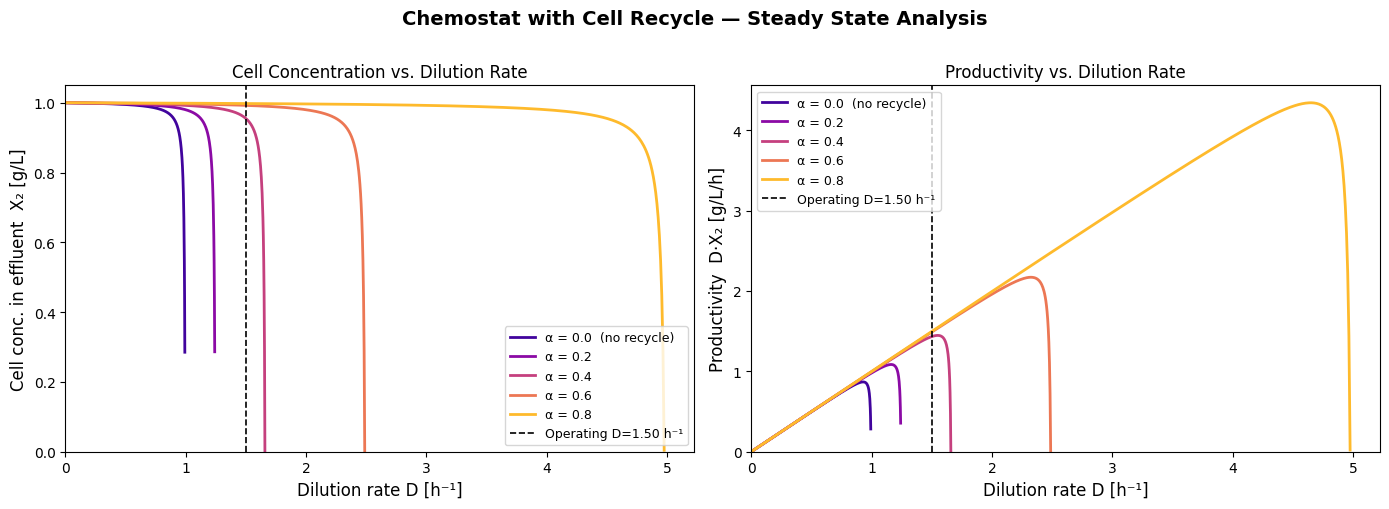

In [8]:
def steady_state(D_val, alpha_val, C_val=C, mu_m_=mu_m, Ks_=Ks, S0_=S0, Yxs_=Yxs):
    """Compute steady-state X1, X2, S, productivity for given D and α."""
    factor = 1 + alpha_val * (1 - C_val)
    mu_val = D_val * factor
    if mu_val <= 0 or mu_val >= mu_m_:
        return np.nan, np.nan, np.nan, np.nan
    S_val  = mu_val * Ks_ / (mu_m_ - mu_val)
    if S_val >= S0_:
        return np.nan, np.nan, np.nan, np.nan
    X1_val = Yxs_ * D_val * (S0_ - S_val) / mu_val
    X2_val = X1_val * factor
    Prod   = D_val * X2_val    # productivity = D * X2 [g/L/h]
    return X1_val, X2_val, S_val, Prod

# ── Plotting ──────────────────────────────────────────────────────────────────
alpha_plot = [0.0, 0.2, 0.4, 0.6, 0.8]
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(alpha_plot)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chemostat with Cell Recycle — Steady State Analysis",
             fontsize=14, fontweight='bold', y=1.01)

ax1, ax2 = axes

for a, col in zip(alpha_plot, colors):
    Dmax_a = mu_m / (1 + a * (1 - C))
    D_range = np.linspace(0.01, Dmax_a * 0.999, 500)

    X2_arr = []
    P_arr  = []
    D_ok   = []

    for d in D_range:
        x1, x2, s, prod = steady_state(d, a)
        if not np.isnan(x2):
            X2_arr.append(x2)
            P_arr.append(prod)
            D_ok.append(d)

    label = f"α = {a}" + ("  (no recycle)" if a == 0 else "")
    ax1.plot(D_ok, X2_arr, color=col, lw=2, label=label)
    ax2.plot(D_ok, P_arr,  color=col, lw=2, label=label)

# Mark the operating point from parts (b-e)
ax1.axvline(D, color='black', ls='--', lw=1.2, label=f"Operating D={D:.2f} h⁻¹")
ax2.axvline(D, color='black', ls='--', lw=1.2, label=f"Operating D={D:.2f} h⁻¹")

ax1.set_xlabel("Dilution rate D [h⁻¹]", fontsize=12)
ax1.set_ylabel("Cell conc. in effluent  X₂ [g/L]", fontsize=12)
ax1.set_title("Cell Concentration vs. Dilution Rate", fontsize=12)
ax1.legend(fontsize=9)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

ax2.set_xlabel("Dilution rate D [h⁻¹]", fontsize=12)
ax2.set_ylabel("Productivity  D·X₂ [g/L/h]", fontsize=12)
ax2.set_title("Productivity vs. Dilution Rate", fontsize=12)
ax2.legend(fontsize=9)
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

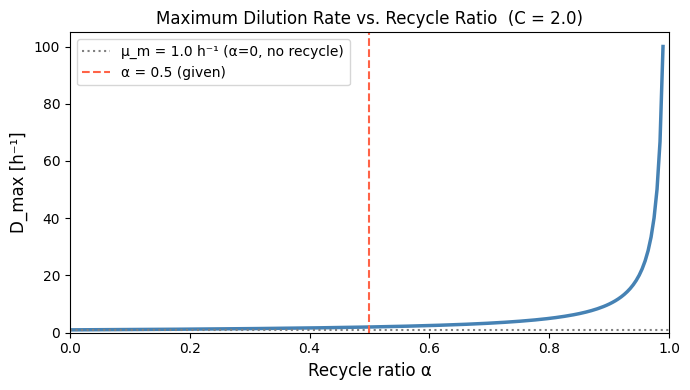

In [9]:
# ── D_max vs α plot ───────────────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 4))
ax.plot(alpha_range, Dmax_vals, color='steelblue', lw=2.5)
ax.axhline(mu_m, color='gray', ls=':', lw=1.5, label=f'μ_m = {mu_m} h⁻¹ (α=0, no recycle)')
ax.axvline(alpha, color='tomato', ls='--', lw=1.5, label=f'α = {alpha} (given)')
ax.set_xlabel("Recycle ratio α", fontsize=12)
ax.set_ylabel("D_max [h⁻¹]", fontsize=12)
ax.set_title(f"Maximum Dilution Rate vs. Recycle Ratio  (C = {C})", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, alpha_max)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Summary and Interpretation

### Numerical Results

| Quantity | Value | Unit |
|----------|-------|------|
| Dilution rate $D$ | 1.500 | h⁻¹ |
| Specific growth rate $\mu$ | 0.750 | h⁻¹ |
| Substrate conc. $S$ | 0.0300 | g/L |
| Cell conc. (fermenter) $X_1$ | 1.9700 | g/L |
| Cell conc. (effluent) $X_2$ | 0.9850 | g/L |

### Interpretation

- **μ < D** is confirmed: cell recycle allows operation above the classical washout dilution rate, since biomass is continuously returned to the reactor, reducing the effective cell loss rate.
- **Higher α → higher D_max**: increasing the recycle ratio (more cells returned) extends the operable range. At $\alpha \to 1/(C-1)$, $D_{max} \to \infty$ theoretically (complete recycle).
- **α = 0** (no recycle): the system behaves as a standard chemostat, with $D_{max} = \mu_m = 1$ h⁻¹. Cell washout occurs at exactly $D = \mu_m$.
- **Productivity $D \cdot X_2$** passes through an optimum: at low $D$, few cells are washed out (low throughput); near $D_{max}$, $X_2$ drops sharply toward zero. The productivity maximum lies between these extremes.
- **Higher α** increases cell retention, yielding higher $X_2$ at the same $D$ and shifting the productivity peak to higher dilution rates — improving overall throughput.

# Exercise 2: Fed-Batch Penicillin Production

In this exercise, we will analyse the production of Penicillin by P. chrysogenum in a fed-batch reactor. We will derive the system equations, simulate the reactor over multiple cycles, and analyze the effects of substrate inhibition.

### a) Derivation of Differential Equations

In a fed-batch system, the volume is not constant. We must start with the fundamental mass balance:
**Rate of Accumulation = Rate In - Rate Out + Rate of Generation/Consumption**

**1. Volume Balance ($V$):**
Since there is a continuous feed at a flow rate $f_0$ and no withdrawal during the feeding phase:
$$\frac{dV}{dt} = f_0$$

**2. Biomass Balance ($X$):**
Total biomass in the tank is $X \cdot V$. Assuming no cells in the feed and neglecting cell maintenance:
$$\frac{d(XV)}{dt} = \mu X V$$
Applying the product rule: $V\frac{dX}{dt} + X\frac{dV}{dt} = \mu X V$
Substituting $\frac{dV}{dt} = f_0$ and dividing by $V$:
$$\frac{dX}{dt} = \mu X - \frac{f_0}{V}X$$

**3. Substrate Balance ($S$):**
Total substrate is $S \cdot V$. The substrate enters at concentration $S_0$ and is consumed for growth.
$$\frac{d(SV)}{dt} = f_0 S_0 - \frac{\mu X V}{Y_{X/S}}$$
$$V\frac{dS}{dt} + S\frac{dV}{dt} = f_0 S_0 - \frac{\mu X V}{Y_{X/S}}$$
Substituting $\frac{dV}{dt} = f_0$ and dividing by $V$:
$$\frac{dS}{dt} = \frac{f_0}{V}(S_0 - S) - \frac{\mu X}{Y_{X/S}}$$

**4. Product Balance ($P$):**
Total product is $P \cdot V$. The product is generated at a specific rate $q_p$.
$$\frac{d(PV)}{dt} = q_p X V$$
$$V\frac{dP}{dt} + P\frac{dV}{dt} = q_p X V$$
$$\frac{dP}{dt} = q_p X - \frac{f_0}{V}P$$

**5. Kinetic Model (Uncompetitive Substrate Inhibition):**
Based on the provided literature (Sivakumarmar et al., 1994.), substrate inhibition occurs at higher levels, often inducing high osmotic shock. For uncompetitive inhibition, the Haldane model (also referred to as Andrews and Noack) is the standard formulation:
$$\mu = \frac{\mu_m S}{K_S + S + \frac{S^2}{K_I}}$$

**Initial Conditions (at t=0):**
* $V(0) = 200$ L
* $X(0) = 30$ g/L
* $S(0) = 0$ g/L
* $P(0) = 0$ g/L

### b) Cycle Time

The tank starts at an initial volume of 200 L and reaches a maximum capacity of 800 L. 
The flow rate is a constant 50 L/h.

$$\text{Volume Added} = V_{max} - V_0 = 800 - 200 = 600 \text{ L}$$
$$\text{Cycle Time (t)} = \frac{\text{Volume Added}}{f_0} = \frac{600}{50} = 12 \text{ hours}$$

One cycle takes exactly 12 hours.

### c)  Time development of glucose and cells over 10 cycles

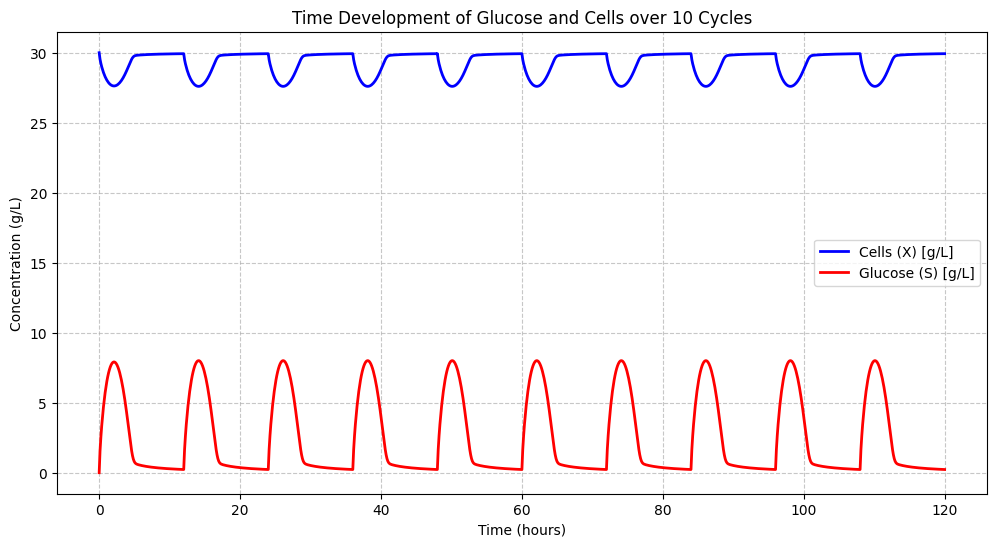

Total product removed over 10 cycles: 136.88 kg


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters ---
f0 = 50.0      # L/h
V0_initial = 200.0 # L
V_max = 800.0  # L
V_removed = 600.0 # L
S0_feed = 100.0 # g/L
mu_m = 0.2     # 1/h
Ks = 0.50      # g/L
Ki = 50.0      # g/L
Yxs = 0.3      # g-cells/g-glucose
qp = 0.08      # g-product/g-cell/h

cycle_time = (V_max - V0_initial) / f0
num_cycles = 10

# --- ODE System ---
def fed_batch_system(t, y, S_feed):
    V, X, S, P = y
    
    # Haldane kinetics for uncompetitive inhibition
    mu = (mu_m * S) / (Ks + S + (S**2 / Ki))
    
    dV_dt = f0
    dX_dt = mu * X - (f0 / V) * X
    dS_dt = (f0 / V) * (S_feed - S) - (mu * X) / Yxs
    dP_dt = qp * X - (f0 / V) * P
    
    return [dV_dt, dX_dt, dS_dt, dP_dt]

# --- c) Simulation over 10 cycles ---
# Initial state: [V, X, S, P]
state = [V0_initial, 30.0, 0.0, 0.0]

time_all = []
V_all = []
X_all = []
S_all = []
P_all = []

total_product_removed_kg = 0.0

for cycle in range(num_cycles):
    t_span = [cycle * cycle_time, (cycle + 1) * cycle_time]
    t_eval = np.linspace(t_span[0], t_span[1], 100)
    
    sol = solve_ivp(fed_batch_system, t_span, state, t_eval=t_eval, args=(S0_feed,), method='LSODA')
    
    time_all.append(sol.t)
    V_all.append(sol.y[0])
    X_all.append(sol.y[1])
    S_all.append(sol.y[2])
    P_all.append(sol.y[3])
    
    # End of cycle values
    V_end = sol.y[0][-1]
    X_end = sol.y[1][-1]
    S_end = sol.y[2][-1]
    P_end = sol.y[3][-1]
    
    # Remove 600 L
    product_removed_grams = V_removed * P_end
    total_product_removed_kg += product_removed_grams / 1000.0
    
    # Reset state for next cycle (Concentrations remain the same, volume drops to 200 L)
    state = [V0_initial, X_end, S_end, P_end]

# Flatten arrays for plotting
time_all = np.concatenate(time_all)
X_all = np.concatenate(X_all)
S_all = np.concatenate(S_all)

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(time_all, X_all, label='Cells (X) [g/L]', color='blue', lw=2)
plt.plot(time_all, S_all, label='Glucose (S) [g/L]', color='red', lw=2)
plt.title('Time Development of Glucose and Cells over 10 Cycles')
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (g/L)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"Total product removed over 10 cycles: {total_product_removed_kg:.2f} kg")

Over 10 cycles, 136.88 kg of product are removed

### d) Substrate Inhibition Analysis

If we observe the substrate concentration $S$ in the plot above, it rises significantly in the early stages of each cycle (and progressively over multiple cycles). 

**Comparing Growth Rates:**
* **Without inhibition (Monod):** If $S$ is high (e.g., $S \gg K_S$), $\mu \approx \mu_m = 0.2/h$.
* **With inhibition (Haldane):** Because $K_I = 50$ g/L, when $S$ accumulates (for example, hitting 20 g/L or more), the $\frac{S^2}{K_I}$ term in the denominator becomes quite large. If $S = 20$ g/L, $\frac{S^2}{K_I} = \frac{400}{50} = 8$. This significantly increases the denominator, suppressing the specific growth rate $\mu$ well below 0.2 /h. 

**Risk of increasing the amount of substrate in the feed:**
If we increase the feed substrate concentration ($S_0$) or the flow rate, the rate at which substrate enters will greatly exceed the rate at which the initial biomass can consume it. This causes $S$ to rapidly accumulate in the reactor. Due to the uncompetitive inhibition, the elevated $S$ further inhibits cellular growth (lowering $\mu$). This creates a cascading failure: slower growth means even less substrate is consumed, leading to further toxic accumulation of substrate and eventual biological washout or process failure.

To clearly see if (and how much) the substrate inhibits the system, we can plot the specific growth rate ($\mu$) as a function of substrate concentration ($S$) for both the uninhibited Monod model and the uncompetitive Haldane model.

<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:17: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

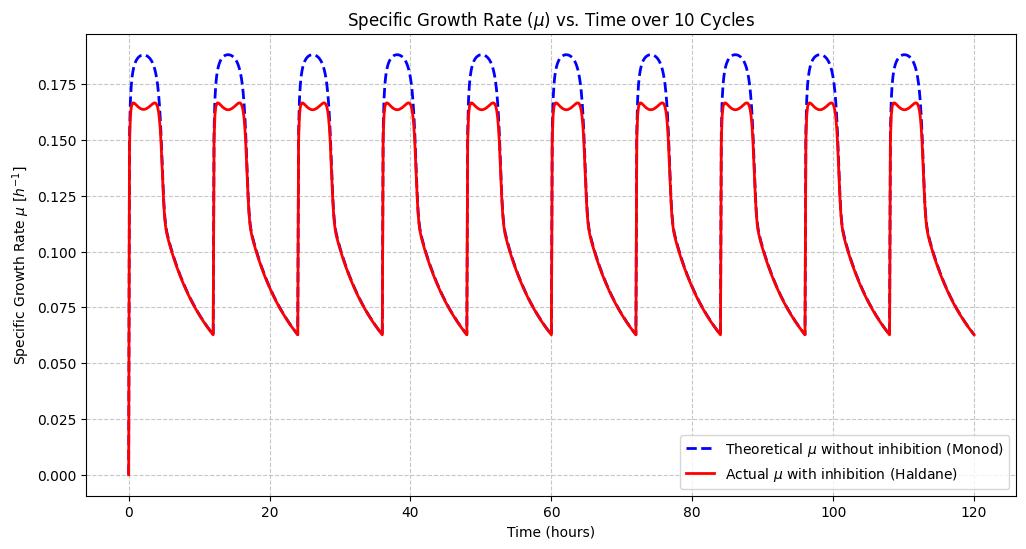

In [11]:
# --- d) Plotting Growth Rate over 10 Cycles ---

# We use the S_all array (glucose concentration over time) from the part c) simulation

# Calculate theoretical Monod growth rate (no inhibition) over time
mu_monod_time = (mu_m * S_all) / (Ks + S_all)

# Calculate actual Haldane growth rate (with uncompetitive inhibition) over time
mu_haldane_time = (mu_m * S_all) / (Ks + S_all + (S_all**2 / Ki))

plt.figure(figsize=(12, 6))
plt.plot(time_all, mu_monod_time, label='Theoretical $\mu$ without inhibition (Monod)', linestyle='--', color='blue', lw=2)
plt.plot(time_all, mu_haldane_time, label='Actual $\mu$ with inhibition (Haldane)', color='red', lw=2)

plt.title('Specific Growth Rate ($\mu$) vs. Time over 10 Cycles')
plt.xlabel('Time (hours)')
plt.ylabel('Specific Growth Rate $\mu$ [$h^{-1}$]')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### e) Advantage of Fed-Batch vs. Batch Culture

The primary advantage of a fed-batch culture for substrate-inhibited systems is concentration control. 
If this were a batch culture, we would have to add the entire required amount of glucose at $t=0$ to reach the desired final biomass. This massive initial concentration would immediately trigger severe substrate inhibition, effectively stalling growth from the very beginning. By using a fed-batch operation, we slowly "drip-feed" the glucose. This allows the cells to consume the substrate roughly at the same rate it is added, keeping the bulk liquid concentration of glucose relatively low and avoiding the inhibitory effects, while still delivering a large total mass of substrate over the entire process.

### f) Optimization of the Reactor Cycle


We can extract the absolute maximum value and the corresponding optimal feed substrate concentration ($S_0$).

--- Optimization Results ---
Optimal Feed Substrate Concentration (S0): 136.67 g/L
Maximum Production Rate (10th cycle): 1610.4945 g/h

Note: The ideal feed S0 balances bringing in enough mass to create product,
while avoiding pushing the internal reactor concentration 'S' far beyond 5.00 g/L,
where severe Haldane inhibition begins.


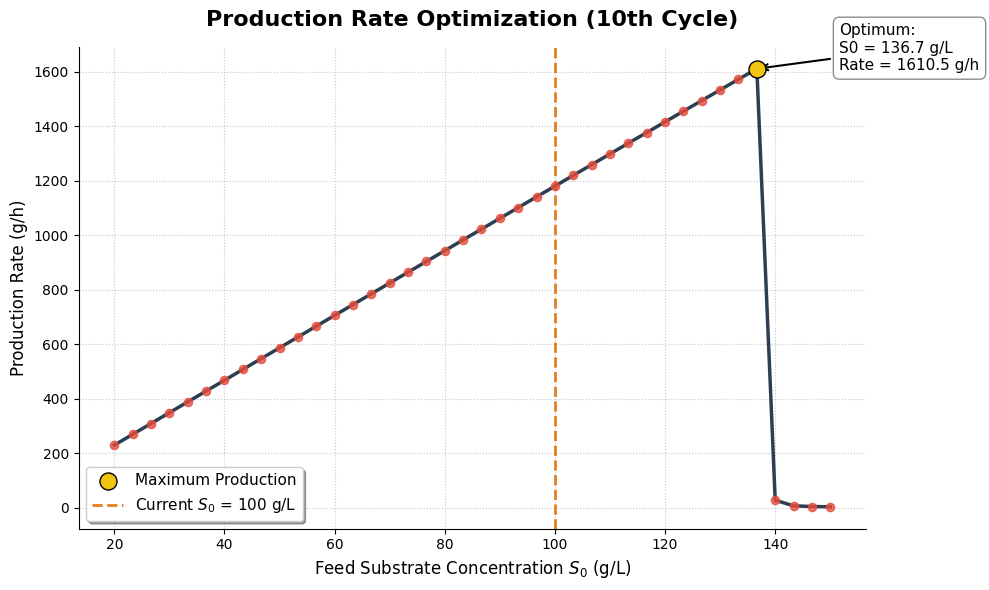

In [12]:
# --- f) Optimization of the Reactor Cycle ---

def calculate_production_rate(S0_val):
    state = [V0_initial, 30.0, 0.0, 0.0]
    total_product = 0.0
    
    for cycle in range(num_cycles):
        t_span = [cycle * cycle_time, (cycle + 1) * cycle_time]
        sol = solve_ivp(fed_batch_system, t_span, state, args=(S0_val,), method='LSODA', max_step=0.5)
        
        P_end = sol.y[3][-1]
        
        # Only record the mass removed in the 10th cycle for the rate calculation, 
        # as per "mass of product removed from 10th cycle / cycle time"
        if cycle == 9: 
            mass_10th_cycle = V_removed * P_end
            
        state = [V0_initial, sol.y[1][-1], sol.y[2][-1], P_end]
        
    return mass_10th_cycle / cycle_time # g/h

# Sweep feed substrate concentrations
S0_range = np.linspace(20, 150, 40)
production_rates = []

for s in S0_range:
    rate = calculate_production_rate(s)
    production_rates.append(rate)

# --- Extracting the Optimal Parameters ---
optimal_index = np.argmax(production_rates)
optimal_S0 = S0_range[optimal_index]
max_production_rate = production_rates[optimal_index]

print("--- Optimization Results ---")
print(f"Optimal Feed Substrate Concentration (S0): {optimal_S0:.2f} g/L")
print(f"Maximum Production Rate (10th cycle): {max_production_rate:.4f} g/h")

# Calculate the theoretical optimal steady-state substrate concentration in the reactor
S_opt_reactor = np.sqrt(Ks * Ki)

print(f"\nNote: The ideal feed S0 balances bringing in enough mass to create product,")
print(f"while avoiding pushing the internal reactor concentration 'S' far beyond {S_opt_reactor:.2f} g/L,")
print(f"where severe Haldane inhibition begins.")

# --- Upgraded Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Main trend line and markers
ax.plot(S0_range, production_rates, color='#2c3e50', linewidth=2.5, zorder=3)
ax.scatter(S0_range, production_rates, color='#e74c3c', s=35, zorder=4, alpha=0.8)

# 2. Highlight the maximum point
ax.scatter([optimal_S0], [max_production_rate], color='#f1c40f', s=150, edgecolor='black', zorder=5, label='Maximum Production')

# Add an arrow pointing to the exact maximum value
ax.annotate(f'Optimum:\nS0 = {optimal_S0:.1f} g/L\nRate = {max_production_rate:.1f} g/h',
            xy=(optimal_S0, max_production_rate), 
            xytext=(optimal_S0 + 15, max_production_rate - 5), # Offset the text
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            fontsize=11, 
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))

# 3. Vertical line for current S0
ax.axvline(x=100, color='#e67e22', linestyle='--', linewidth=2, label=r'Current $S_0$ = 100 g/L', zorder=2)

# 4. Typography and Labels
ax.set_title('Production Rate Optimization (10th Cycle)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel(r'Feed Substrate Concentration $S_0$ (g/L)', fontsize=12)
ax.set_ylabel('Production Rate (g/h)', fontsize=12)

# 5. Clean up the grid and borders
ax.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend positioning
ax.legend(loc='lower left', frameon=True, fontsize=11, shadow=True)

plt.tight_layout()
plt.show()

# Exercise 3: Two Continuous Stirred Tank Reactors (CSTRs) in Series

### Problem Statement
We consider a biological system consisting of two continuous stirred tank reactors (CSTRs) operating in series under steady-state conditions. The goal is to predict the outlet concentrations of cell mass ($X$) and substrate ($S$) for various volume configurations and compare them to a single 1000 L reactor.

**Given Parameters:**
* Flow rate: $F = 100 \text{ L/h}$
* Inlet substrate concentration: $S_0 = 10 \text{ g/L}$
* Yield coefficient: $Y_{X/S} = 0.5 \text{ g cells/g substrate}$
* Maximum growth rate: $\mu_{\max} = 1 \text{ h}^{-1}$
* Monod constant: $K_S = 0.75 \text{ g/L}$

**Assumptions:**
1. Steady-state operation.
2. Maintenance energy of the cells is negligible.
3. The specific growth rate follows Monod kinetics: $\mu(S) = \mu_{\max} \frac{S}{K_S + S}$
4. The feed entering the first reactor is sterile ($X_0 = 0$).

### Mathematical Model

The system is modeled using mass balances for both biomass and substrate across both reactors. The general balance equation is: **Accumulation = In - Out + Generation/Consumption**. Under steady-state conditions, Accumulation = 0.

#### Reactor 1 Balances
Reactor 1 receives a sterile feed.
* **Biomass:**
    $$0 = - D_1 X_1 + \mu(S_1) X_1$$
* **Substrate:**
    $$0 = D_1 (S_0 - S_1) - \frac{1}{Y_{X/S}} \mu(S_1) X_1$$

#### Reactor 2 Balances
Reactor 2 is fed directly by the effluent of Reactor 1. Therefore, the biomass balance must account for the cells entering the reactor ($D_2 X_1$).
* **Biomass:**
    $$0 = D_2 X_1 - D_2 X_2 + \mu(S_2) X_2$$
* **Substrate:**
    $$0 = D_2 (S_1 - S_2) - \frac{1}{Y_{X/S}} \mu(S_2) X_2$$

Where the dilution rate is defined as $D_i = \frac{F}{V_i}$.

In [13]:
import numpy as np
from scipy.optimize import fsolve

# Define Parameters 
F = 100      # L/h
S0 = 10      # g/L
Yxs = 0.5    # g/g
mu_max = 1.0 # h^-1
Ks = 0.75    # g/L

# Define the Non-Linear System
def system(vars, V1, V2):
    S1, X1, S2, X2 = vars
    
    # Dilution rates
    D1 = F / V1
    D2 = F / V2
    
    # Monod kinetics
    mu1 = mu_max * S1 / (Ks + S1)
    mu2 = mu_max * S2 / (Ks + S2)
    
    # Reactor 1 Balances (sterile feed)
    eq1 = -D1 * X1 + mu1 * X1 
    eq2 = D1 * (S0 - S1) - (1 / Yxs) * mu1 * X1
    
    # Reactor 2 Balances (receives X1 and S1 from Reactor 1)
    eq3 = D2 * X1 - D2 * X2 + mu2 * X2
    eq4 = D2 * (S1 - S2) - (1 / Yxs) * mu2 * X2
    
    return [eq1, eq2, eq3, eq4]

def solve_case(V1, V2):
    # Initial guess assumes active biomass. If a reactor washes out, 
    # the solver will naturally drive X down to 0 and S up to 10.
    initial_guess = [0.5, 4.5, 0.5, 4.5] 
    
    # full_output=True allows us to monitor solver convergence
    sol, infodict, ier, mesg = fsolve(system, initial_guess, args=(V1, V2), full_output=True)
    
    if ier != 1:
        print(f"  [!] Warning: Solver struggled to converge for V1={V1}, V2={V2}.")
        
    return sol

### Simulation and Results

We will now solve the non-linear system for the four proposed volume configurations, as well as a baseline single 1000 L reactor, and compare the final outlet concentrations.

In [14]:
# 1. Run the Single Reactor Baseline
def single_reactor(vars):
    S, X = vars
    D = F / 1000
    mu = mu_max * S / (Ks + S)
    
    eq1 = -D * X + mu * X
    eq2 = D * (S0 - S) - (1 / Yxs) * mu * X
    return [eq1, eq2]

S_sing, X_sing = fsolve(single_reactor, [0.5, 4.5])
print("=== Single Reactor Result (1000 L) ===")
print(f"  Outlet: S = {S_sing:.3f} g/L, X = {X_sing:.3f} g/L\n")

# 2. Run the Two-Stage Configurations
cases = {
    "a": (800, 200),
    "b": (200, 800),
    "c": (900, 100),
    "d": (100, 900),
}

print("=== Two-Stage Reactor Configurations ===")
for key, (V1, V2) in cases.items():
    S1, X1, S2, X2 = solve_case(V1, V2)
    
    # Clean up near-zero floating point artifacts (e.g., -1.2e-15 -> 0.0)
    S1, X1 = max(0.0, S1), max(0.0, X1)
    S2, X2 = max(0.0, S2), max(0.0, X2)

    print(f"Case {key}) V1 = {V1} L, V2 = {V2} L:")
    print(f"  Reactor 1: S1 = {S1:.3f} g/L, X1 = {X1:.3f} g/L")
    print(f"  Reactor 2: S2 = {S2:.3f} g/L, X2 = {X2:.3f} g/L\n")

=== Single Reactor Result (1000 L) ===
  Outlet: S = 0.083 g/L, X = 4.958 g/L

=== Two-Stage Reactor Configurations ===
Case a) V1 = 800 L, V2 = 200 L:
  Reactor 1: S1 = 0.107 g/L, X1 = 4.946 g/L
  Reactor 2: S2 = 0.004 g/L, X2 = 4.998 g/L

Case b) V1 = 200 L, V2 = 800 L:
  Reactor 1: S1 = 0.750 g/L, X1 = 4.625 g/L
  Reactor 2: S2 = 0.007 g/L, X2 = 4.996 g/L

Case c) V1 = 900 L, V2 = 100 L:
  Reactor 1: S1 = 0.094 g/L, X1 = 4.953 g/L
  Reactor 2: S2 = 0.007 g/L, X2 = 4.997 g/L

Case d) V1 = 100 L, V2 = 900 L:
  Reactor 1: S1 = 10.000 g/L, X1 = 0.000 g/L
  Reactor 2: S2 = 0.094 g/L, X2 = 4.953 g/L



### Analysis and Comparison

**Single Reactor Baseline (1000 L):**
* **Final Output:** $S = 0.083 \text{ g/L}$, $X = 4.958 \text{ g/L}$
* In a single CSTR, the specific growth rate must exactly equal the dilution rate ($\mu = D$). To achieve a low substrate concentration, the dilution rate must be kept low, which limits the overall throughput.

**Two-Stage Configuration Analysis:**
The data reveals that dividing the total 1000 L volume into two active stages (Cases A, B, and C) drastically improves the efficiency of the system compared to a single reactor. 

* Cases A, B, and C: In all three of these configurations, the final substrate concentration drops to near-zero levels ($0.004 \text{ to } 0.007 \text{ g/L}$), heavily outperforming the single 1000 L reactor ($0.083 \text{ g/L}$). 
    * *Why this happens:* In Reactor 2, the biomass is constantly replenished by the inflow from Reactor 1. The mathematical consequence is that Reactor 2 is no longer bound by the $\mu = D$ constraint. Because it doesn't need to grow fast enough to overcome washout, $\mu_2$ can drop to near zero. A tiny $\mu_2$ correlates to a tiny $S_2$, allowing Reactor 2 to act as a highly efficient "polishing" stage that scrubs the remaining substrate from the liquid.
    * Case A ($S_2 = 0.004 \text{ g/L}$) is technically the most efficient at consuming substrate, though Cases B and C are practically identical in performance.

* **Case D (V1 = 100 L, V2 = 900 L) - The Washout Condition:**
    * **Final Output:** $S_2 = 0.094 \text{ g/L}$, $X_2 = 4.953 \text{ g/L}$
    * In this configuration, $V_1 = 100 \text{ L}$ and $F = 100 \text{ L/h}$, meaning the dilution rate $D_1 = 1.0 \text{ h}^{-1}$. Because $\mu_{\max}$ is also $1.0 \text{ h}^{-1}$, the specific growth rate can never exceed the dilution rate. Consequently, **Reactor 1 completely washes out** ($X_1 = 0 \text{ g/L}$, $S_1 = 10 \text{ g/L}$). 
    * Because Reactor 1 fails to cultivate any biomass, it acts merely as a pipe feeding raw substrate into Reactor 2. Reactor 2 is forced to act as a standalone 900 L reactor, which explains why its final output ($S = 0.094 \text{ g/L}$) is slightly worse than the baseline 1000 L reactor.

**Conclusion:**
This simulation illustrates why fermentations with separated growth and product-formation steps utilize multiple reactors in series. By using a first reactor to cultivate a dense biomass population, the second reactor is freed from the strict $\mu = D$ growth constraints. This allows the second reactor to operate at extreme efficiencies, driving substrate levels down to nearly zero and maximizing the final cell yield.

## Bonus - Chemostat with Mixed-Growth-Associated Product Formation (Luedeking-Piret)

### System Equations

The growth rate follows Monod kinetics:
$$\mu = \frac{\mu_m S}{K_s + S}$$

Mass balances in a chemostat (constant volume):
$$\frac{dX}{dt} = \mu X - DX$$
$$\frac{dS}{dt} = D(S_0 - S) - \frac{\mu X}{Y_{x/s}}$$
$$\frac{dP}{dt} = (\alpha \mu + \beta) X - DP$$

The term $(\alpha \mu + \beta)$ is the **Luedeking-Piret model**:
product formation is partly growth-associated ($\alpha \mu$)
and partly non-growth-associated ($\beta$, maintenance).

### Steady State

At steady state, $dX/dt = 0$, therefore $\mu = D$.

Inverting Monod:
$$S = \frac{K_s D}{\mu_m - D}$$

Substrate balance:
$$X = Y_{x/s}(S_0 - S)$$

Product balance ($dP/dt = 0$):
$$P = \frac{(\alpha D + \beta) X}{D}$$

The **productivities** are defined as:
$$\Pi_P = D \cdot P \quad \text{and} \quad \Pi_X = D \cdot X$$

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (all in g/L)
mu_m  = 0.7    # h^-1
Ks    = 0.02   # g/L  (= 20 mg/L converted)
Yxs   = 0.5    # g cell / g substrate
alpha = 0.1    # g P / g X (growth-associated)
beta  = 0.02   # h^-1 (non-growth-associated production)
S0    = 1      # g/L
P0    = 0      # g/L

# Steady state functions
def S_ss(D):
    """Substrate concentration at SS from mu(S)=D"""
    if D >= mu_m:
        return np.nan
    return Ks * D / (mu_m - D)

def X_ss(D):
    """Cell concentration at SS"""
    S = S_ss(D)
    if np.isnan(S) or S > S0:
        return 0.0
    return Yxs * (S0 - S)

def P_ss(D):
    """Product concentration at SS"""
    if D == 0:
        return np.nan
    X = X_ss(D)
    return (alpha * D + beta) * X / D

def prod_P(D):
    return D * P_ss(D)

def prod_X(D):
    return D * X_ss(D)

In [16]:
D_vals = np.linspace(1e-4, mu_m - 1e-4, 2000)

pP = np.array([prod_P(D) for D in D_vals])
pX = np.array([prod_X(D) for D in D_vals])

idx_P  = np.nanargmax(pP)
idx_X  = np.nanargmax(pX)

D_opt_P = D_vals[idx_P]
D_opt_X = D_vals[idx_X]

print(f"Optimal dilution rate for PRODUCT productivity:")
print(f"  D_opt = {D_opt_P:.4f} h⁻¹")
print(f"  Pi_P  = {pP[idx_P]:.4f} g/L/h")
print()
print(f"Optimal dilution rate for BIOMASS productivity:")
print(f"  D_opt = {D_opt_X:.4f} h⁻¹")
print(f"  Pi_X  = {pX[idx_X]:.4f} g/L/h")

Optimal dilution rate for PRODUCT productivity:
  D_opt = 0.5889 h⁻¹
  Pi_P  = 0.0353 g/L/h

Optimal dilution rate for BIOMASS productivity:
  D_opt = 0.6019 h⁻¹
  Pi_X  = 0.2640 g/L/h


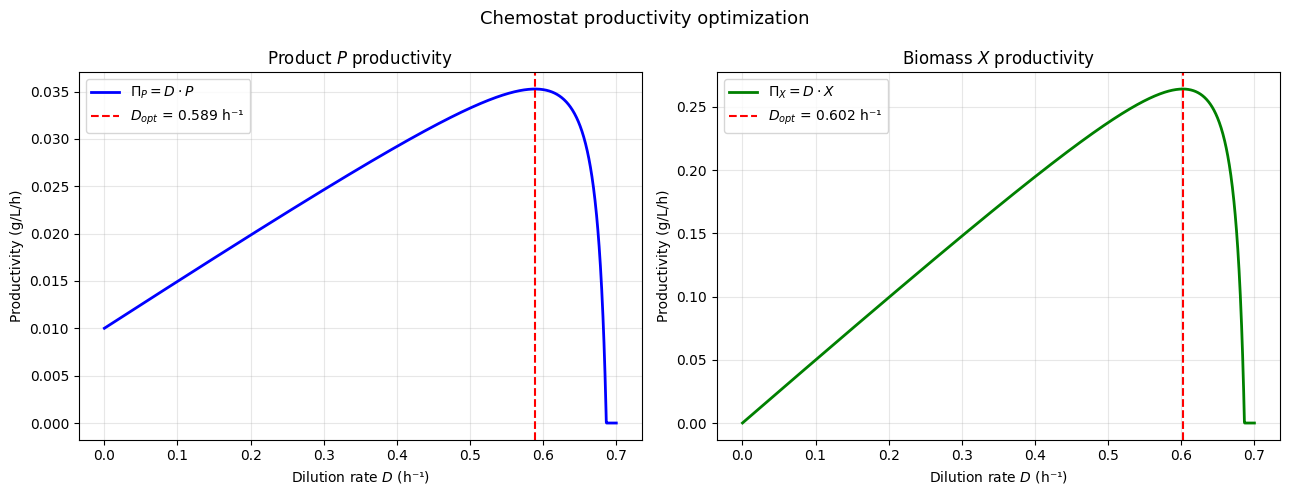

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Product productivity ---
axes[0].plot(D_vals, pP, 'b-', lw=2, label='$\\Pi_P = D \\cdot P$')
axes[0].axvline(D_opt_P, color='r', ls='--', label=f'$D_{{opt}}$ = {D_opt_P:.3f} h⁻¹')
axes[0].set_xlabel('Dilution rate $D$ (h⁻¹)')
axes[0].set_ylabel('Productivity (g/L/h)')
axes[0].set_title('Product $P$ productivity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Biomass productivity ---
axes[1].plot(D_vals, pX, 'g-', lw=2, label='$\\Pi_X = D \\cdot X$')
axes[1].axvline(D_opt_X, color='r', ls='--', label=f'$D_{{opt}}$ = {D_opt_X:.3f} h⁻¹')
axes[1].set_xlabel('Dilution rate $D$ (h⁻¹)')
axes[1].set_ylabel('Productivity (g/L/h)')
axes[1].set_title('Biomass $X$ productivity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Chemostat productivity optimization', fontsize=13)
plt.tight_layout()
plt.show()

## Interpretation of Results

### Why is D_opt(P) ≠ D_opt(X)?

For **biomass**, the productivity $\Pi_X = D \cdot Y_{x/s}(S_0 - S(D))$
is maximized at an intermediate D: increasing D raises throughput but
lowers $X$ (less residence time → less substrate consumed).

For the **product**, there is an extra $\beta/D$ term in the expression for $P$:
$$P = \left(\alpha + \frac{\beta}{D}\right) X$$

This term favors **low D** values (more residence time → more non-growth-associated
production). The optimum of $\Pi_P$ is therefore shifted toward lower D
compared to $\Pi_X$.

### Washout limit

When $D \to \mu_m$, $S \to S_0$ and $X \to 0$:
cells are diluted faster than they grow → **washout**.
Both productivities drop to zero.

### Conclusion

The optimal D depends on what we want to maximize.
If the added value lies in the **product** (e.g. penicillin),
we operate at a lower D than if we want to maximize **biomass**.